In [1]:
# Import all required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Conv1D, Flatten, Dropout, concatenate
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# Load dataset

data = pd.read_csv("/kaggle/input/datasets/dheerajmg/soil-data/Soil data.csv")

data.head()

,District,Nitrogen Value,Phosphorous value,Potassium value,pH
0,Yadgir,28.736,67.103,78.602,7.0954
1,Yadgir,22.229,62.822,75.221,7.3273
2,Yadgir,22.145,70.373,77.868,7.0311
3,Yadgir,26.321,72.488,76.697,7.0470
4,Yadgir,26.687,72.183,75.068,7.0078


In [3]:
# Remove unnecessary column

data = data.drop(columns=["District"])

# Rename columns for simplicity
data.columns = ["N", "P", "K", "pH"]

data.head()

,N,P,K,pH
0,28.736,67.103,78.602,7.0954
1,22.229,62.822,75.221,7.3273
2,22.145,70.373,77.868,7.0311
3,26.321,72.488,76.697,7.0470
4,26.687,72.183,75.068,7.0078


In [4]:
# Create nutrient stress labels based on thresholds

def stress_label(row):
    
    if row["N"] < 50 or row["P"] < 30 or row["K"] < 30:
        return "Deficient"
    
    elif row["pH"] < 5.5 or row["pH"] > 8:
        return "Stress"
    
    else:
        return "Normal"

data["Stress"] = data.apply(stress_label, axis=1)

data.head()

,N,P,K,pH,Stress
0,28.736,67.103,78.602,7.0954,Deficient
1,22.229,62.822,75.221,7.3273,Deficient
2,22.145,70.373,77.868,7.0311,Deficient
3,26.321,72.488,76.697,7.0470,Deficient
4,26.687,72.183,75.068,7.0078,Deficient


In [5]:
# Separate features and target

X = data[["N", "P", "K", "pH"]]
y = data["Stress"]

In [6]:
# Convert labels to numbers

le = LabelEncoder()
y = le.fit_transform(y)

# Convert to categorical (one-hot)
y = to_categorical(y)

In [7]:
# Scale features

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [8]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
# Reshape input for CNN-LSTM

X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

In [10]:
# Compute class weights to handle imbalance

from sklearn.utils.class_weight import compute_class_weight

# Convert one-hot to labels
y_train_labels = np.argmax(y_train, axis=1)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

# Convert to dictionary
class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights)

Class Weights: {0: np.float64(0.5131964809384164), 1: np.float64(19.444444444444443)}


In [11]:
# Build CNN-LSTM model with dropout

input_layer = Input(shape=(1, X_train.shape[2]))

# CNN branch
cnn = Conv1D(filters=32, kernel_size=1, activation='relu')(input_layer)
cnn = Dropout(0.3)(cnn)
cnn = Flatten()(cnn)

# LSTM branch
lstm = LSTM(32)(input_layer)
lstm = Dropout(0.3)(lstm)

# Combine
combined = concatenate([cnn, lstm])

dense1 = Dense(64, activation='relu')(combined)
dense1 = Dropout(0.4)(dense1)

output = Dense(y_train.shape[1], activation='softmax')(dense1)

model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1, 4)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1, 32)     │        160 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1, 32)     │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 32)        │      4,736 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 32)        │          0 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 2)         │        130 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,186 (35.88 KB)

 Trainable params: 9,186 (35.88 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Early stopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [13]:
# Train model with class weights

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    class_weight=class_weights   # IMPORTANT LINE
)

Epoch 1/50


I0000 00:00:1776421659.199024      95 cuda_dnn.cc:529] Loaded cuDNN version 91002


22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9142 - loss: 0.9817 - val_accuracy: 0.9486 - val_loss: 0.3866
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9349 - loss: 0.6432 - val_accuracy: 0.9200 - val_loss: 0.3125
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9050 - loss: 0.3469 - val_accuracy: 0.9029 - val_loss: 0.2472
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9143 - loss: 0.2697 - val_accuracy: 0.9086 - val_loss: 0.2041
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9018 - loss: 0.1928 - val_accuracy: 0.9143 - val_loss: 0.1750
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9219 - loss: 0.1612 - val_accuracy: 0.9257 - val_loss: 0.1576
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9213 - loss: 0.1351 - val_accuracy: 0.9257 - val_loss: 0.1494
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9020 - loss: 0.1806 - val_accuracy: 0.9371 - val_loss: 0.154

In [14]:
# Train model with class weights

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    class_weight=class_weights   # IMPORTANT LINE
)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9396 - loss: 0.1042 - val_accuracy: 0.9429 - val_loss: 0.1365
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9525 - loss: 0.0747 - val_accuracy: 0.9543 - val_loss: 0.1359
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9365 - loss: 0.3840 - val_accuracy: 0.9429 - val_loss: 0.1394
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9485 - loss: 0.0974 - val_accuracy: 0.9429 - val_loss: 0.1433
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9468 - loss: 0.0881 - val_accuracy: 0.9486 - val_loss: 0.1419
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9389 - loss: 0.0969 - val_accuracy: 0.9600 - val_loss: 0.1350
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9548 - loss: 0.1066 - val_accuracy: 0.9600 - val_loss: 0.1381
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9549 - loss: 0.0847 - val_accuracy: 0.9600 - val_loss

In [15]:
# Evaluate model performance on test data

loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9654 - loss: 0.1208 
Test Loss: 0.1347247213125229
Test Accuracy: 0.9599999785423279


In [16]:
# Get predictions from model
y_pred = model.predict(X_test)

# Convert probabilities → class index
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert one-hot y_test → class index
y_true = np.argmax(y_test, axis=1)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


In [17]:
# Create comparison table (Actual vs Predicted)

results_df = pd.DataFrame({
    "Actual": le.inverse_transform(y_true),
    "Predicted": le.inverse_transform(y_pred_classes)
})

# Show first 20 rows
results_df.head(20)

,Actual,Predicted
0,Deficient,Deficient
1,Deficient,Deficient
2,Deficient,Deficient
3,Deficient,Deficient
4,Deficient,Deficient
5,Deficient,Deficient
6,Deficient,Deficient
7,Deficient,Deficient
8,Deficient,Deficient
9,Deficient,Deficient


In [18]:
# Calculate accuracy manually

correct = np.sum(y_true == y_pred_classes)
total = len(y_true)

print("Correct Predictions:", correct)
print("Total Samples:", total)
print("Manual Accuracy:", correct / total)

Correct Predictions: 168
Total Samples: 175
Manual Accuracy: 0.96


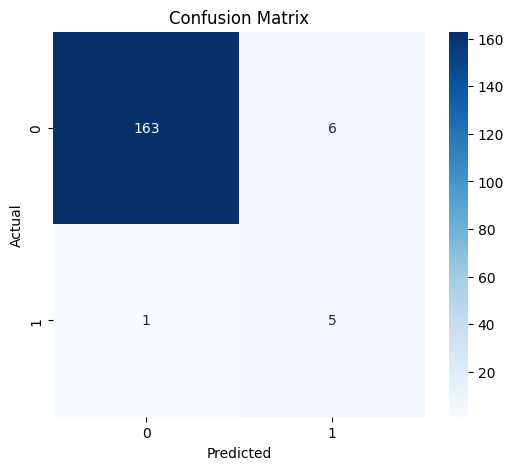

In [19]:
# Plot confusion matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [20]:
# Print classification metrics

from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.99      0.96      0.98       169
           1       0.45      0.83      0.59         6

    accuracy                           0.96       175
   macro avg       0.72      0.90      0.78       175
weighted avg       0.98      0.96      0.97       175



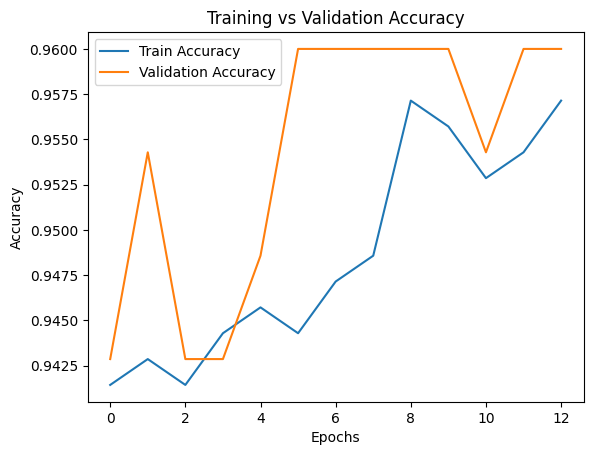

In [21]:
# Plot training vs validation accuracy

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()

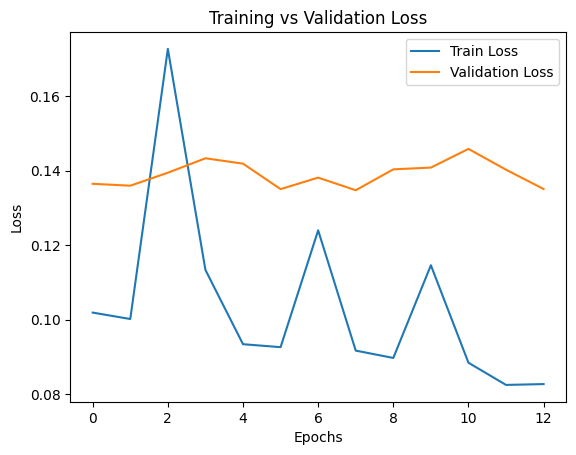

In [22]:
# Plot training vs validation loss

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [23]:
# Test model with custom inputs

samples = [
    [80, 40, 45, 6.5],   # Normal
    [20, 10, 15, 5.0],   # Deficient
    [120, 90, 95, 8.5]   # Stress
]

samples = np.array(samples)

# Scale input
samples_scaled = scaler.transform(samples)

# Reshape for model
samples_scaled = samples_scaled.reshape(samples_scaled.shape[0], 1, samples_scaled.shape[1])

# Predict
predictions = model.predict(samples_scaled)

pred_classes = np.argmax(predictions, axis=1)

labels = le.inverse_transform(pred_classes)

# Print results
for i in range(len(samples)):
    print("Input:", samples[i])
    print("Predicted Condition:", labels[i])
    print("--------------")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Input: [80.  40.  45.   6.5]
Predicted Condition: Normal
--------------
Input: [20. 10. 15.  5.]
Predicted Condition: Deficient
--------------
Input: [120.   90.   95.    8.5]
Predicted Condition: Normal
--------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


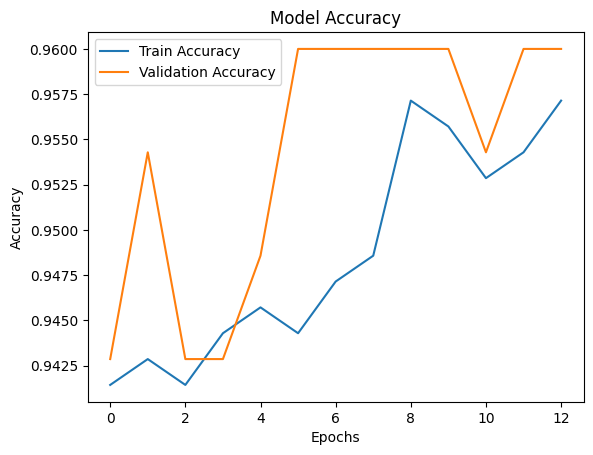

In [24]:
# Plot training vs validation accuracy

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()
plt.show()

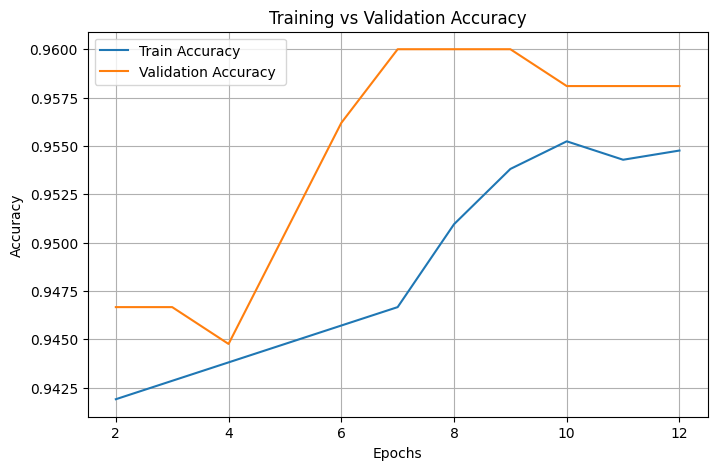

In [25]:
# Plot SMOOTH accuracy graph (better visualization)

import pandas as pd

train_acc = pd.Series(history.history['accuracy']).rolling(window=3).mean()
val_acc = pd.Series(history.history['val_accuracy']).rolling(window=3).mean()

plt.figure(figsize=(8,5))

plt.plot(train_acc, label='Train Accuracy ')
plt.plot(val_acc, label='Validation Accuracy ')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.grid(True)
plt.show()

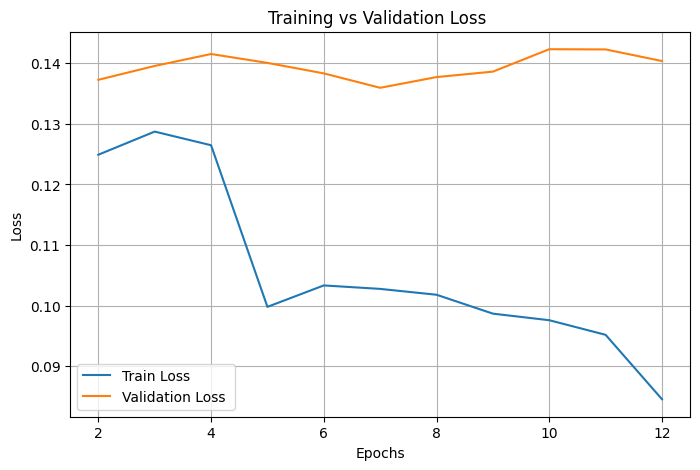

In [26]:
# Plot SMOOTH loss graph

train_loss = pd.Series(history.history['loss']).rolling(window=3).mean()
val_loss = pd.Series(history.history['val_loss']).rolling(window=3).mean()

plt.figure(figsize=(8,5))

plt.plot(train_loss, label='Train Loss ')
plt.plot(val_loss, label='Validation Loss ')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss ")
plt.legend()

plt.grid(True)
plt.show()